# Linear heat conduction problem with different materials, with full order and reduced order simulations.

![Problem Schematic](problem_schematics.png)


## Environment Setup

### Directories

In [1]:
import sys
from pathlib import Path
import importlib

nb_folder = Path().resolve()
PROBLEM_NAME = nb_folder.name
parent_folder = nb_folder.parent
if str(parent_folder) not in sys.path:
    sys.path.insert(0, str(parent_folder))

### Standard Imports

In [2]:
#Standard Imports and class import
from skrom.utils.imports import *
from skrom.rom.rom_utils import *
from skrom.utils.reduced_basis.svd import svd_mode_selector
from skrom.rom.rom_error_est import *
from skrom.utils.visualization.color_palette import set_color_palette
import skrom.problem_classes.static.master_class as master
problem_mod = importlib.import_module(f"{PROBLEM_NAME}.problem_def") #- this runs @register_problem

### Plot Properties

In [3]:
set_color_palette();

## Full Order Simulation

In [4]:
# Control flag for expensive simulation generation

generate = True

# Conditional execution block for simulation data generation
if generate:
    # Create an instance of the linear heat conduction simulation
    sim =  master.fom_simulation()

    sim.run_simulation()

Snap 1/64 params=[  -3.56445667 -748.34933504]
Snap 2/64 params=[  1.24114645 849.36711192]
Snap 3/64 params=[   2.00135199 -264.96038958]
Snap 4/64 params=[ -0.67729806 145.38170397]
Snap 5/64 params=[  -1.50552588 -113.84155788]
Snap 6/64 params=[  3.17312393 483.51225443]
Snap 7/64 params=[ 6.91302419e-02 -8.80418519e+02]
Snap 8/64 params=[ -2.73647264 529.30964716]
Snap 9/64 params=[  -2.29887127 -404.56803516]
Snap 10/64 params=[0.88173191 5.64626604]
Snap 11/64 params=[   3.86075509 -608.74024406]
Snap 12/64 params=[ -1.44289491 989.10018057]
Snap 13/64 params=[-3.64880353e-01 -7.70121532e+02]
Snap 14/64 params=[  2.9387694  639.73061182]
Snap 15/64 params=[   1.80347333 -224.13709946]
Snap 16/64 params=[ -3.37712961 373.08892049]
Snap 17/64 params=[  -3.03001464 -137.11057417]
Snap 18/64 params=[  1.66633555 273.3516898 ]
Snap 19/64 params=[   2.59166978 -872.52893858]
Snap 20/64 params=[-2.27727339e-01  7.25551819e+02]
Snap 21/64 params=[  -1.08699165 -506.57318532]
Snap 22/64 

### Load Simulation Data

In [5]:
#Load the ROM_data
current_dir = Path().resolve()
rom_dir = current_dir / "ROM_data"
fos_solutions, sim_data = load_rom_data(self = None, rom_data_dir=rom_dir)


[load_rom_data] loaded from /Users/syedabidi/Documents/GitHub/scikit-rom/examples/heat_transfer/static/linear/problem_2/ROM_data


## Data Generation

### Generate training solution dataset

In [6]:
# Convert parameter list to a NumPy array (representing system parameters)
# This contains the parameter values for each simulation run (e.g., thermal conductivity, 
# boundary conditions, material properties, etc.)
param_list = np.asarray(sim_data['param_list'])

# Load non-linear solutions from the full-order system
# NLS contains the high-fidelity finite element solutions for each parameter set
# Each row represents a complete solution snapshot (discretized spatial field)
LS = np.asarray(fos_solutions)

# Split data into training and testing using predefined masks
# These boolean masks determine which snapshots are used for ROM training vs validation
train_mask, test_mask = sim_data['train_mask'], sim_data['test_mask']

# Apply masks to filter non-linear solutions for training and testing
# Training set: Used to construct the ROM basis functions and train the model
LS_train = LS[train_mask]  # Training snapshots with Dirichlet boundary conditions applied

# Testing set: Used to evaluate ROM accuracy and performance on unseen data
LS_test = LS[test_mask]    # Testing snapshots with Dirichlet boundary conditions applied

# Get the number of snapshots (parameter samples or time instances)
# N_snap: Total number of simulation snapshots available
# Second dimension: Number of degrees of freedom (DOFs) in the spatial discretization
N_snap, _ = np.shape(LS)

# Display the total number of snapshots for verification
print(N_snap)  # Print the number of snapshots available


64


### Training Solution Snapshots

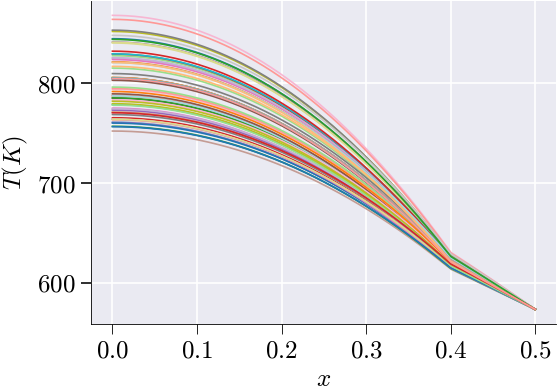

In [7]:
# Plot the computed temperature distribution
# Create a figure with specified dimensions (5x3.5 inches) for compact visualization
plt.figure(figsize=(5, 3.5))

# Extract spatial coordinates from the mesh data
# The mesh is stored as an object in sim_data, accessed via .item() to get the actual mesh
# mesh.p[0] contains the x-coordinates of the mesh nodes (1D spatial domain)
mesh_domain = sim_data['mesh'].item().p[0]

# Plot temperature profiles for all parameter combinations
# Loop through all non-linear solutions (each row is a complete temperature field)
for j in range(len(LS)):
    # Plot each temperature distribution as a line
    # x-axis: spatial coordinates from the mesh
    # y-axis: temperature values at each spatial location
    # '-' specifies solid line style, markersize affects any markers
    plt.plot(mesh_domain, LS[j], '-', markersize=2)

# Set axis labels with proper mathematical notation
plt.xlabel("$x$")        # Spatial coordinate (LaTeX formatting)
plt.ylabel("$T (K)$")    # Temperature in Kelvin (LaTeX formatting)

# Display the plot
plt.show()

### Mean Subtraction

In [8]:
# Compute the mean temperature field across all training snapshots
# This represents the "average" or "reference" temperature distribution
# Shape: [N_dof] - one mean value for each spatial degree of freedom
LS_train_mean = np.mean(LS_train,axis = 0)
# Mean-center the training data by subtracting the mean field
# This creates fluctuations/deviations from the mean temperature distribution
# Shape: [N_train_snapshots, N_dof] - same as original but now mean-centered
# Each row now represents how much each snapshot deviates from the average
LS_train_ms = LS_train - LS_train_mean
#We will use SVD on the mean subtracted matrix data

### Distribution of training parameters

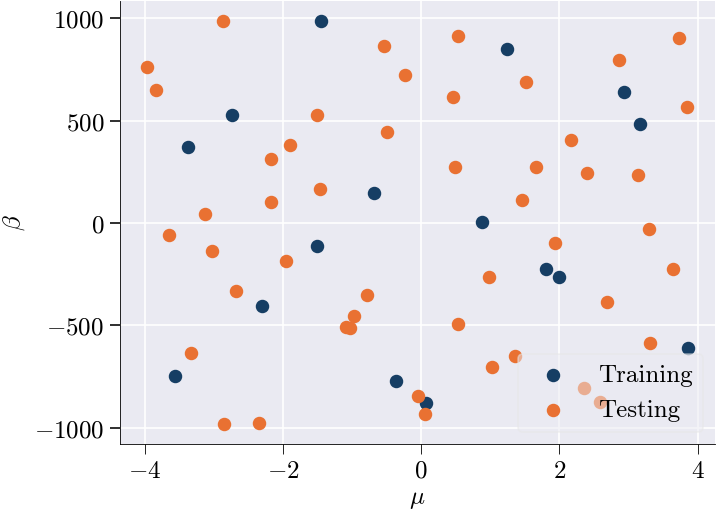

In [9]:
# Visualize the parameter space distribution for training and testing data
# Plot training parameter combinations (first 16 samples)
# Extract first and second parameter columns for 2D visualization
plt.scatter(param_list[:16][:, 0],    # First parameter (μ) for training samples which are the k_params 
           param_list[:16][:, 1],     # Second parameter (β) for training samples which are the q_params
           s=50,                      # Marker size
           c='#163e64',              # Dark blue color for training points
           label="Training")         # Legend label

# Plot testing parameter combinations (samples 17 and beyond)
plt.scatter(param_list[16:][:, 0],    # First parameter (μ) for testing samples
           param_list[16:][:, 1],     # Second parameter (β) for testing samples
           s=50,                      # Marker size (same as training)
           c='#e97132',              # Orange color for testing points
           label="Testing")          # Legend label

# Set axis labels using LaTeX formatting for mathematical notation
plt.xlabel("$\\mu$")        # First parameter (often material property, conductivity, etc.) this is the k_params
plt.ylabel("$\\beta$")     # Second parameter (often boundary condition, heat source, etc.) this is the q_params

# Add legend to distinguish between training and testing sets
plt.legend()

#See params and properties to see how these are used

### Performing SVD on training snapshots

Number of modes selected: 4


Text(0.5, 0, 'POD modes ($k$)')

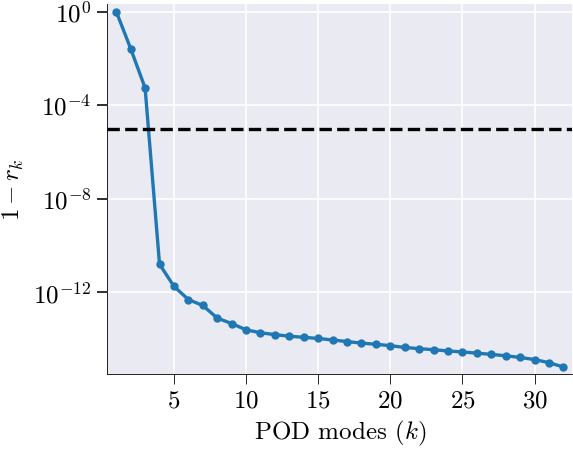

In [10]:
# fig, ax = plt.subplots(figsize=(5,3.5))
plt.rcParams['lines.markersize'] = 6
plt.rcParams['lines.linewidth'] = 2.0

n_sel, U = svd_mode_selector(LS_train_ms, tolerance = 1e-5,modes=True)
n_sel = n_sel + 1
V_sel = U[:, :n_sel]#This will be passed in my simulation function
plt.ylabel('$1-r_{k}$')
plt.xlabel('POD modes ($k$)')

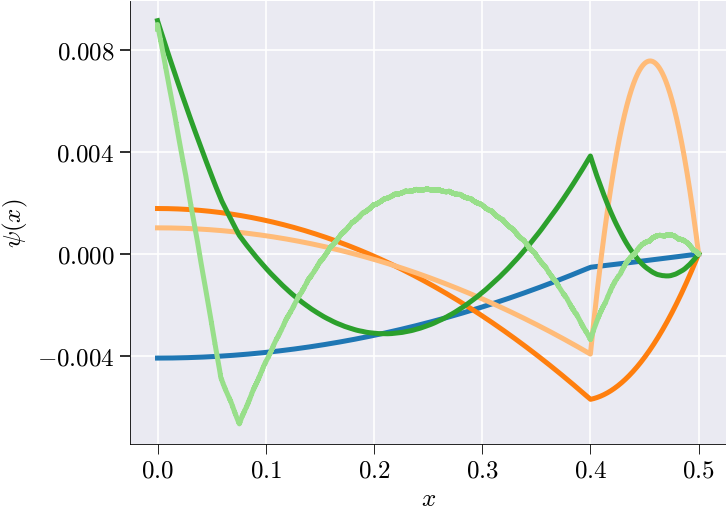

In [11]:
fig, ax = plt.subplots()

for i in range(n_sel):
    plt.plot(mesh_domain, V_sel[:,i],lw=3)

ax.set_xlabel('$x$')
ax.set_ylabel('$\\psi(x)$')
    
ax.yaxis.set_major_locator(MaxNLocator(nbins=5)) 
plt.show()

## ROM Simulation

In [12]:
# Initialize the reduced-order model (ROM) simulation with affine decomposition for speed-up
#   V_sel : precomputed basis matrix (e.g., selected POD modes)
rom = master.rom_simulation(V_sel=V_sel)

[load_rom_data] loaded from /Users/syedabidi/Documents/GitHub/scikit-rom/examples/heat_transfer/static/linear/problem_2/ROM_data


In [13]:
# Run the reduced-order model (ROM) simulation.
# rom object will contain the NLS rom simulation solutions and other simulation aspects required by ROM such as the param_list etc.
rom.run_rom_simulation();

Snap 1/64 params=[-5.44742972e-01  8.66633264e+02]
Snap 2/64 params=[   2.68338354 -385.07814147]
Snap 3/64 params=[  1.46598917 114.13319968]
Snap 4/64 params=[  -3.32344712 -634.64373536]
Snap 5/64 params=[ -2.16947687 312.66431324]
Snap 6/64 params=[ 5.81765845e-02 -9.34647733e+02]
Snap 7/64 params=[  3.84127053 566.02076255]
Snap 8/64 params=[  -1.94866934 -186.17885001]
Snap 9/64 params=[ -1.4571404  167.73668304]
Snap 10/64 params=[   3.31447363 -584.94739607]
Snap 11/64 params=[5.36017433e-01 9.14500397e+02]
Snap 12/64 params=[  -2.67477509 -333.30374584]
Snap 13/64 params=[ -3.83230158 652.85702422]
Snap 14/64 params=[  1.93981602 -95.43544427]
Snap 15/64 params=[  2.16087151 405.48488125]
Snap 16/64 params=[-4.94479612e-02 -8.45734429e+02]
Snap 17/64 params=[ -0.49654254 445.02969645]
Snap 18/64 params=[   2.35392894 -807.16902204]
Snap 19/64 params=[  1.51224124 691.4224308 ]
Snap 20/64 params=[ -3.65094383 -55.89062907]
Snap 21/64 params=[ -2.87127645 985.29235087]
Snap 22/6

In [14]:
#Assign values for the statistics
LS_rom = np.asarray(rom.rom_solutions)
ROM_speed_up = rom.speed_up
ROM_speed_up=ROM_speed_up[1:]
ROM_relative_error = rom.rom_error

### ROM solution vs. Full order solution performance statistics 

ROM Accuracy Report

Global Errors:
L2 Error:                 6.4468e-06
Relative L2 Error:        4.3980e-12
L∞ Error:                 2.1342e-08
Relative L∞ Error:        2.4694e-11
RMSE:                     3.1478e-09
MAE:                      1.4701e-09

Statistical Fit:
R² Score:                 1.0000
Explained Variance:       1.0000

Error Distribution:
Median Error:             -1.7781e-10
95th Percentile Error:    7.6686e-09

Time/Parameter-Dependent Errors:
Average Rel L2 Error over time/parameter: 2.3908e-12
Max Rel L2 Error over time/parameter: 1.5699e-11
Min Rel L2 Error over time/parameter: 9.4242e-14
―――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――

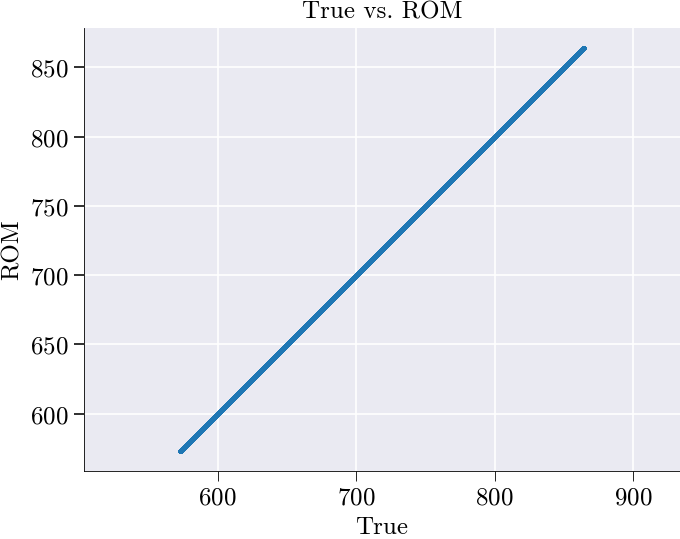

spatial_shape not given → skipping spatial snapshots.
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


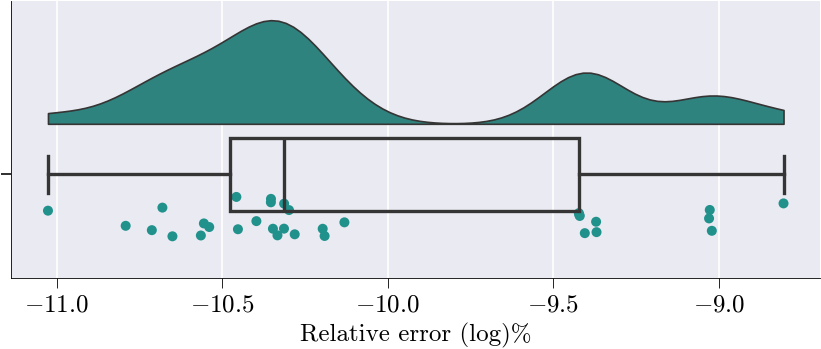

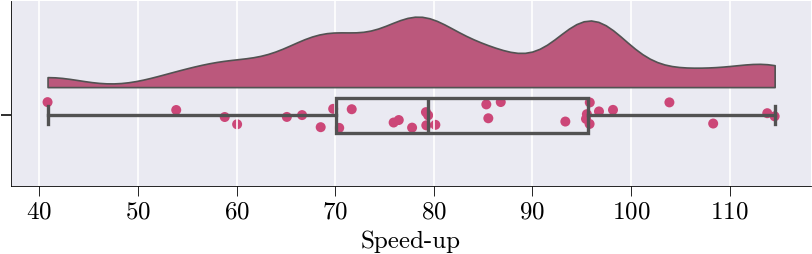

In [15]:
# --- ROM error analysis ---

# Compute a flat matrix of error metrics comparing true nonlinear solutions to hyper-ROM approximations
matrix = compute_rom_error_metrics_flat(LS_test, LS_rom)

# Produce a text-based report summarizing these hyper-ROM error metrics
generate_rom_error_report(matrix)

# Plot diagnostic figures: error vs. speed-up for the hyper-reduced ROM
plot_rom_error_diagnostics_flat(
    LS_test,                   # full-order (true) solution snapshots
    LS_rom,              # hyper-ROM-generated solution snapshots
    ROM_relative_error,   # precomputed relative error of the hyper-ROM
    ROM_speed_up,         # precomputed speed-up factor of the hyper-ROM
    sim_axis=['True', 'ROM'], 
    metrics=matrix              # the matrix of error metrics just computed
)
